## Decision Tree of Trees
Classifying the difference between Evergreen vs Deciduous Trees using a decision tree

## Step 1: Imports

In [ ]:
# Imports
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import metrics

## Step 2: Load Dataset


The dataset is loaded from Kaggle Hub. It is a 2023 dataset covering Minecraft Blocks, Items, Mobs, and Biomes.

Documentation:
- https://www.kaggle.com/datasets/madelinee/minecraft-blocks-items-mobs-biomes-etc?resource=download&select=Mobs.csv

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("madelinee/minecraft-blocks-items-mobs-biomes-etc")

print("Path to dataset files:", path)

100%|██████████| 20.5k/20.5k [00:00<00:00, 21.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/madelinee/minecraft-blocks-items-mobs-biomes-etc/versions/1


In [ ]:
mobs_file_path = os.path.join(path, "Mobs.csv")

if os.path.exists(mobs_file_path):
    mobs_df = pd.read_csv(mobs_file_path)
    display(mobs_df.head())
else:
    print(
        f"{mobs_file_path} does not exist. "
        "Check the printed directory tree for the exact subfolder."
    )

print(f"Dataset shape: {mobs_df.shape}")

,ID,name,behaviorTypes,spawnBehavior,healthPoints,maxDamage,debutDate,minecraftVersion,reproductiveRequirement
0,1,sniffer_egg,Peaceful,Player Summoned,0,0.0,2023-06-07T00:00:00,1.20.0,NaN
1,2,turtle_egg,Peaceful,Player Summoned,0,0.0,2018-07-18T00:00:00,1.13.0,NaN
2,3,bat,Peaceful,Random,6,NaN,2012-10-25T00:00:00,1.4.2,NaN
3,4,blaze,Hostile,On Load,20,6.0,2011-11-18T00:00:00,1.0.0,NaN
4,5,chicken,Peaceful,Random,4,NaN,2011-11-18T00:00:00,1.0.0,Wheat Seeds


Dataset shape: (78, 9)


## Step 3: Data Exploration

In [ ]:
# Info
mobs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       78 non-null     int64  
 1   name                     78 non-null     object 
 2   behaviorTypes            78 non-null     object 
 3   spawnBehavior            78 non-null     object 
 4   healthPoints             78 non-null     int64  
 5   maxDamage                56 non-null     float64
 6   debutDate                78 non-null     object 
 7   minecraftVersion         78 non-null     object 
 8   reproductiveRequirement  24 non-null     object 
dtypes: float64(1), int64(2), object(6)
memory usage: 5.6+ KB


In [ ]:
# Describe
mobs_df.describe()

,ID,healthPoints,maxDamage
count,78.000000,78.000000,56.000000
mean,39.500000,31.358974,7.803571
std,22.660538,68.010117,10.971732
min,1.000000,0.000000,0.000000
25%,20.250000,10.000000,2.750000
50%,39.500000,16.000000,5.000000
75%,58.750000,23.000000,8.000000
max,78.000000,500.000000,68.000000


In [ ]:
# Check for missing values (shouldn't be too small since it's a smaller dataset)
print("n\Missing Values: ")
mobs_df.isna().sum()

n\Missing Values: 


<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_3287/3547986894.py:3: SyntaxWarning: invalid escape sequence '\M'
  print("n\Missing Values: ")


,0
ID,0
name,0
behaviorTypes,0
spawnBehavior,0
healthPoints,0
maxDamage,22
debutDate,0
minecraftVersion,0
reproductiveRequirement,54


In [ ]:
mobs_df.head(10)

,ID,name,behaviorTypes,spawnBehavior,healthPoints,maxDamage,debutDate,minecraftVersion,reproductiveRequirement
0,1,sniffer_egg,Peaceful,Player Summoned,0,0.0,2023-06-07T00:00:00,1.20.0,NaN
1,2,turtle_egg,Peaceful,Player Summoned,0,0.0,2018-07-18T00:00:00,1.13.0,NaN
2,3,bat,Peaceful,Random,6,NaN,2012-10-25T00:00:00,1.4.2,NaN
3,4,blaze,Hostile,On Load,20,6.0,2011-11-18T00:00:00,1.0.0,NaN
4,5,chicken,Peaceful,Random,4,NaN,2011-11-18T00:00:00,1.0.0,Wheat Seeds
5,6,dolphin,Conditional,Random,10,3.0,2018-07-18T00:00:00,1.13.0,NaN
6,7,endermite,Hostile,Player Summoned,8,2.0,2014-09-02T00:00:00,1.8.0,NaN
7,8,guardian,Hostile,On Load,30,6.0,2014-09-02T00:00:00,1.8.0,NaN
8,9,guardian_elder,Hostile,On Load,80,8.0,2014-09-02T00:00:00,1.8.0,NaN
9,10,phantom,Hostile,Night,20,2.0,2018-07-18T00:00:00,1.13.0,NaN


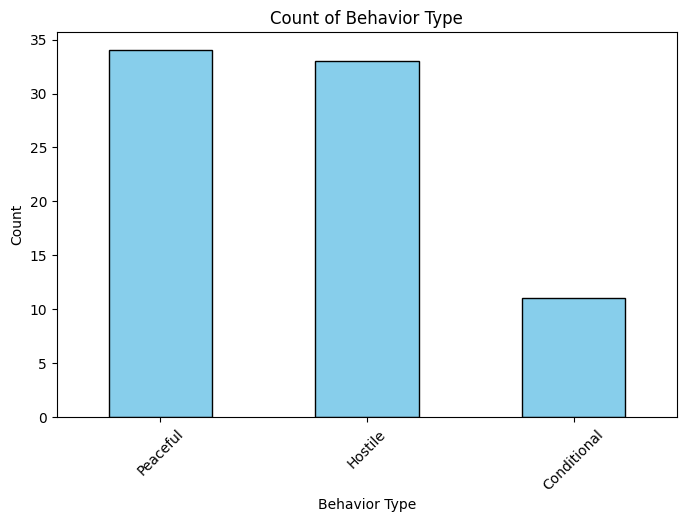

In [ ]:
behavior_types = mobs_df['behaviorTypes'].value_counts()

plt.figure(figsize=(8, 5))
behavior_types.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Count of Behavior Type")
plt.xlabel("Behavior Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Addressing the "Conditional" category

So we have a category called conditional. The behavior of these creatures is "conditional" on the player's behavior. Since conditional means the creature has the ability to be hostile, we will label them under the hostile category.

In other words, conditional animals are not always hostile, but conditional animals can be hostile. Since peaceful creatures are unable to be hostile, we can't put conditional under peaceful.

In [ ]:
# Change 'Conditional' behavior types to 'Hostile'
mobs_df['behaviorTypes'] = mobs_df['behaviorTypes'].replace('Conditional', 'Hostile')

# Verify the changes
mobs_df['behaviorTypes'].value_counts()

,count
behaviorTypes,
Hostile,44
Peaceful,34


## Step 4: Clean & Prepare the Data

In [ ]:
# Step 1: Separte features (X) and target (y)
y = mobs_df['behaviorTypes']
X = mobs_df.drop('behaviorTypes', axis=1).copy()

In [ ]:
# Step 2: Calculating prevalence to prevent guessing
prevalence = y.value_counts(normalize=True)
print("Class Prevalence: \n")
print(prevalence)

majority_class = prevalence.idxmax()
baseline_accuracy = prevalence.max()

print(f"\nMajority Class: {majority_class}")
print(f"Baseline Accuracy to beat: {baseline_accuracy:.2%}")

Class Prevalence: 

behaviorTypes
Hostile     0.564103
Peaceful    0.435897
Name: proportion, dtype: float64

Majority Class: Hostile
Baseline Accuracy to beat: 56.41%


## Collapse Factor Levels

In [ ]:
mobs_df.head()

,ID,name,behaviorTypes,spawnBehavior,healthPoints,maxDamage,debutDate,minecraftVersion,reproductiveRequirement
0,1,sniffer_egg,Peaceful,Player Summoned,0,0.0,2023-06-07T00:00:00,1.20.0,NaN
1,2,turtle_egg,Peaceful,Player Summoned,0,0.0,2018-07-18T00:00:00,1.13.0,NaN
2,3,bat,Peaceful,Random,6,NaN,2012-10-25T00:00:00,1.4.2,NaN
3,4,blaze,Hostile,On Load,20,6.0,2011-11-18T00:00:00,1.0.0,NaN
4,5,chicken,Peaceful,Random,4,NaN,2011-11-18T00:00:00,1.0.0,Wheat Seeds


In [ ]:
# Inspect the value counts of categorical features to decide if we need to collapse factors
categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"--- {col} ---")
    print(X[col].value_counts(dropna=False))
    print("\n")

--- name ---
name
sniffer_egg        1
turtle_egg         1
bat                1
blaze              1
chicken            1
                  ..
wolf_tame          1
drowned            1
husk               1
zombie             1
zombie_villager    1
Name: count, Length: 78, dtype: int64


--- spawnBehavior ---
spawnBehavior
Random             43
On Load            14
Player Summoned    11
Night              10
Name: count, dtype: int64


--- debutDate ---
debutDate
2011-11-18T00:00:00    22
2018-07-18T00:00:00     9
2019-04-23T00:00:00     6
2012-10-25T00:00:00     5
2014-09-02T00:00:00     5
2020-06-23T00:00:00     5
2016-11-14T00:00:00     4
2022-06-07T00:00:00     4
2021-06-08T00:00:00     3
2023-06-07T00:00:00     3
2013-07-01T00:00:00     3
2016-06-08T00:00:00     3
2017-06-07T00:00:00     2
2012-03-01T00:00:00     2
2019-12-10T00:00:00     1
2016-02-29T00:00:00     1
Name: count, dtype: int64


--- minecraftVersion ---
minecraftVersion
1.0.0     22
1.13.0     9
1.14.0     6
1.8.0 

### Feature Engineering
Dropping unique identifiers and binarizing sparse categorical features.

In [ ]:
# Drop the 'name' column as it's a unique identifier and won't help the model
X = X.drop('name', axis=1)

# Collapse 'reproductiveRequirement' into a binary feature: 1 if it can reproduce (not NaN), 0 otherwise
X['canReproduce'] = X['reproductiveRequirement'].notna().astype(int)
X = X.drop('reproductiveRequirement', axis=1)

# Display the updated dataframe to verify changes
display(X.head())

,ID,spawnBehavior,healthPoints,maxDamage,debutDate,minecraftVersion,canReproduce
0,1,Player Summoned,0,0.0,2023-06-07T00:00:00,1.20.0,0
1,2,Player Summoned,0,0.0,2018-07-18T00:00:00,1.13.0,0
2,3,Random,6,NaN,2012-10-25T00:00:00,1.4.2,0
3,4,On Load,20,6.0,2011-11-18T00:00:00,1.0.0,0
4,5,Random,4,NaN,2011-11-18T00:00:00,1.0.0,1


In [ ]:
# Drop the ID column
X = X.drop('ID', axis=1)

# Fill missing values in 'maxDamage' with 0
X['maxDamage'] = X['maxDamage'].fillna(0)

# Extract the year from 'debutDate' as a new numerical feature
X['debutYear'] = pd.to_datetime(X['debutDate']).dt.year

# Drop the high-cardinality columns
X = X.drop(['debutDate', 'minecraftVersion'], axis=1)

# Display the final features and verify no missing values remain
display(X.head())
print("\nMissing values after cleaning:")
print(X.isna().sum())

,spawnBehavior,healthPoints,maxDamage,canReproduce,debutYear
0,Player Summoned,0,0.0,0,2023
1,Player Summoned,0,0.0,0,2018
2,Random,6,0.0,0,2012
3,On Load,20,6.0,0,2011
4,Random,4,0.0,1,2011



Missing values after cleaning:
spawnBehavior    0
healthPoints     0
maxDamage        0
canReproduce     0
debutYear        0
dtype: int64


## Step 5: Partitioning the Data

Split into training, tuning, ant testing sets

In [ ]:
# Split data into 80% temp (for train/val) and 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
# Split temp into 60% train and 20% validation (which is 25% of the 80% temp data)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp,
)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (46, 5)
Validation set shape: (16, 5)
Test set shape: (16, 5)


In [ ]:
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Build decision tree pipeline with OneHotEncoder preprocessing
# We use OneHotEncoder because 'spawnBehavior' has no inherent order.
dt_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ],
        remainder='passthrough'
    )),
    ('classifier', DecisionTreeClassifier(random_state=42, criterion='gini', max_depth=3))
])

# Evaluate with 5-fold cross-validation on training data
cv_scores = cross_val_score(
    dt_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print(f"5-Fold CV Accuracy Scores: {cv_scores}")
print(f"Average CV Accuracy: {cv_scores.mean():.2%} (+/- {cv_scores.std() * 2:.2%})")

# Fit final model on full training data
dt_model = dt_pipeline.fit(X_train, y_train)
print("\nPipeline fitted successfully on the training data!")

5-Fold CV Accuracy Scores: [1.         0.88888889 1.         0.77777778 1.        ]
Average CV Accuracy: 93.33% (+/- 17.78%)

Pipeline fitted successfully on the training data!


## Evaluation Metrics

Scoring the model performance

In [ ]:
# Generate pedictions and predicted probabilities
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)

# Train Set
train_pred = dt_model.predict(X_train)
test_pred = dt_model.predict(X_test)

print("Train accuracy:", metrics.accuracy_score(y_train, train_pred))
print("Test accuracy:", metrics.accuracy_score(y_test, test_pred))

# Put into a DataFrame
results = pd.DataFrame({
    'target': y_test,
    'pred': dt_pred,
    'prob_edible': dt_prob[: ,0],
    'prob_poisonous': dt_prob[:, 1]
})


Train accuracy: 0.9782608695652174
Test accuracy: 0.8125


## Confusion Matrix

Shows where the model is getting confused

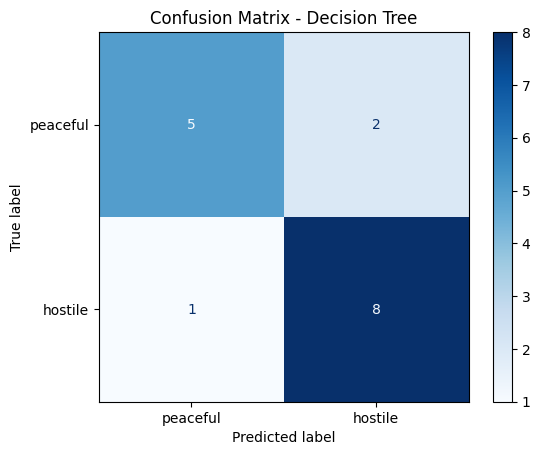

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, dt_pred, labels=['Peaceful', 'Hostile'])

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["peaceful", "hostile"],
)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

##### See above, only 16 mobs because the matrix only shows the test set

However, it only made 3 mistakes out of 16 which is pretty good, but we can probably improve it

## True Positive Rate + False Positive Rate

In [ ]:
# Get metrics
tn, fp, fn, tp = metrics.confusion_matrix(
    y_test,
    dt_pred,
    labels=["Peaceful", "Hostile"],
).ravel()

# Calculate TPR and FPR
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR): {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

True Positive Rate (TPR): 0.8889
False Positive Rate (FPR): 0.2857


## Classification Report

In [ ]:
# Print classification report
print(metrics.classification_report(y_test, dt_pred))

# Print CV scores
print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std. CV accuracy:", cv_scores.std())

              precision    recall  f1-score   support

     Hostile       0.80      0.89      0.84         9
    Peaceful       0.83      0.71      0.77         7

    accuracy                           0.81        16
   macro avg       0.82      0.80      0.81        16
weighted avg       0.81      0.81      0.81        16

CV scores: [1.         0.88888889 1.         0.77777778 1.        ]
Mean CV accuracy: 0.9333333333333332
Std. CV accuracy: 0.0888888888888889


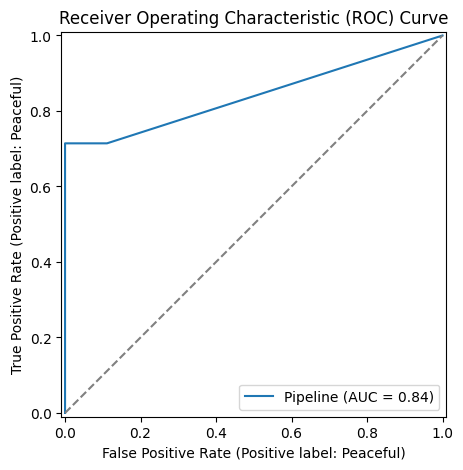


AUC (using 'Peaceful' as positive class): 0.8413


In [ ]:
import matplotlib.pyplot as plt
from sklearn import metrics

# Plot the ROC Curve
fig, ax = plt.subplots(figsize=(7, 5))
metrics.RocCurveDisplay.from_estimator(dt_model, X_test, y_test, ax=ax)
ax.plot([0, 1], [0, 1], color='gray', linestyle='--') # Add diagonal baseline
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.show()

# Calculate AUC explicitly
# dt_model.classes_ contains ['Hostile', 'Peaceful']
# We will use the probabilities of the second class (index 1) to calculate AUC
pos_class = dt_model.classes_[1]
y_test_binary = (y_test == pos_class).astype(int)
auc_score = metrics.roc_auc_score(y_test_binary, dt_prob[:, 1])

print(f"\nAUC (using '{pos_class}' as positive class): {auc_score:.4f}")

## How can we get better?

# Hyperparameter Tuning

Using GridSearchCV to find the optimal parameters for the Decision Tree to reduce overfitting and improve test accuracy.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid to search over
# Note: We use 'classifier__' prefix because the DecisionTree is inside a Pipeline
param_grid = {
    'classifier__max_depth': [2, 3, 4, 5, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__criterion': ['gini', 'entropy']
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    dt_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and the best CV score
print("Best Parameters Found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest Cross-Validation Accuracy: {grid_search.best_score_:.2%}")

# Get the best model and evaluate on the test set
best_dt_model = grid_search.best_estimator_
optimized_pred = best_dt_model.predict(X_test)

print(f"\nOptimized Test Accuracy: {metrics.accuracy_score(y_test, optimized_pred):.2%}")
print("\nOptimized Classification Report:")
print(metrics.classification_report(y_test, optimized_pred))

Best Parameters Found:
  classifier__criterion: gini
  classifier__max_depth: 3
  classifier__min_samples_leaf: 1
  classifier__min_samples_split: 2

Best Cross-Validation Accuracy: 93.33%

Optimized Test Accuracy: 81.25%

Optimized Classification Report:
              precision    recall  f1-score   support

     Hostile       0.80      0.89      0.84         9
    Peaceful       0.83      0.71      0.77         7

    accuracy                           0.81        16
   macro avg       0.82      0.80      0.81        16
weighted avg       0.81      0.81      0.81        16



## Visualize the Decision Tree
Let's look at the actual rules the model learned to separate Hostile and Peaceful mobs.

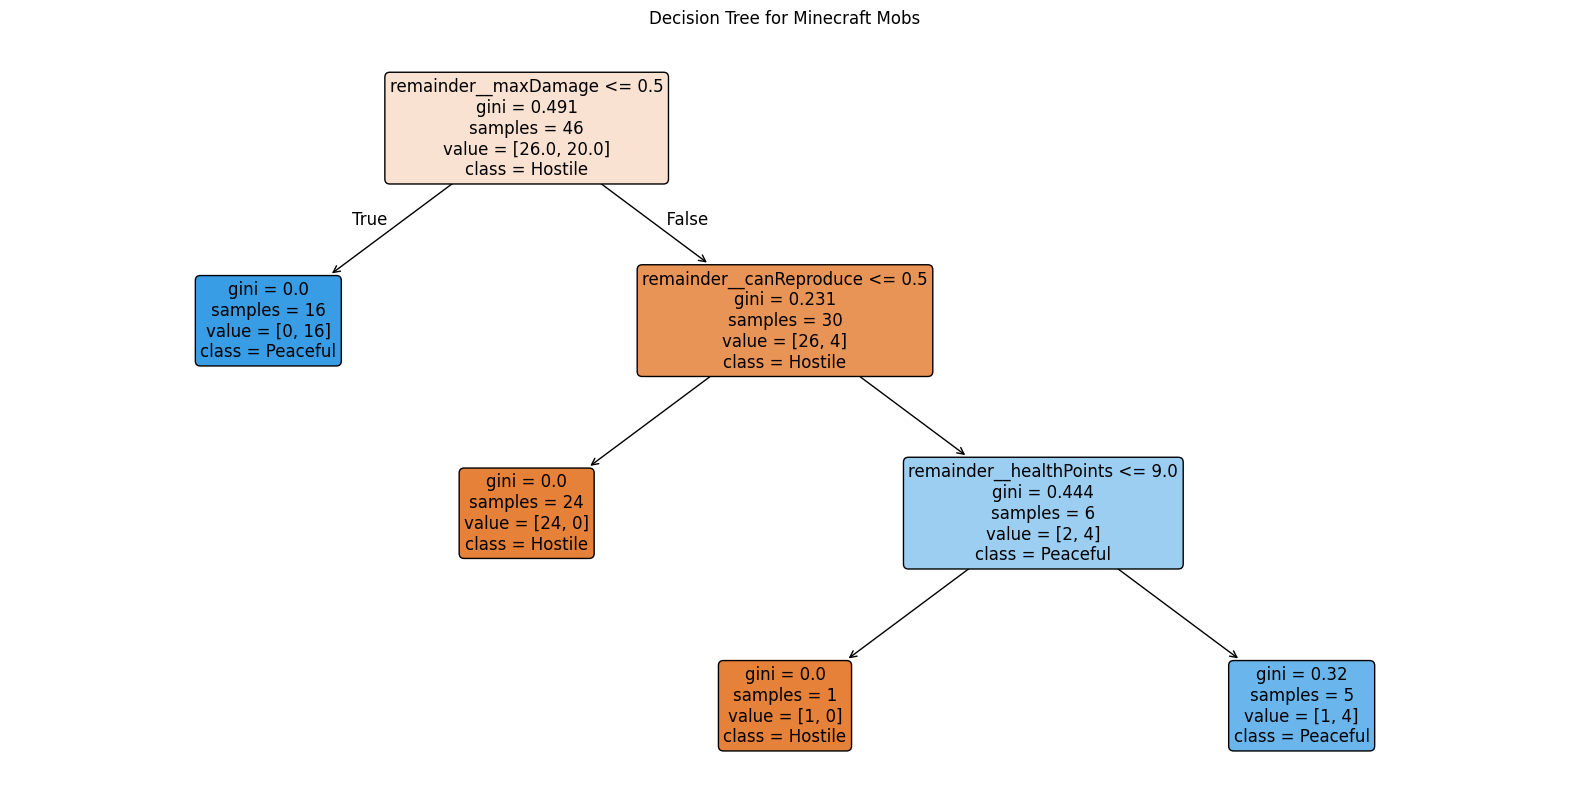

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Extract the preprocessor and the decision tree classifier from the best pipeline
preprocessor = best_dt_model.named_steps['preprocessor']
classifier = best_dt_model.named_steps['classifier']

# Get the feature names after OneHotEncoding
feature_names = preprocessor.get_feature_names_out()

# Set up the plot
plt.figure(figsize=(20, 10))

# Plot the tree
plot_tree(
    classifier,
    feature_names=feature_names,
    class_names=classifier.classes_,
    filled=True,
    rounded=True,
    fontsize=12
)

plt.title('Decision Tree for Minecraft Mobs')
plt.show()

## Random Forest
Let's see if an ensemble of trees (Random Forest) can improve our test accuracy over a single Decision Tree.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Build Random Forest pipeline
rf_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ],
        remainder='passthrough'
    )),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100, max_depth=3))
])

# Evaluate with 5-fold cross-validation on training data
rf_cv_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print(f"Random Forest 5-Fold CV Accuracy: {rf_cv_scores.mean():.2%} (+/- {rf_cv_scores.std() * 2:.2%})")

# Fit on the full training data and evaluate on the test set
rf_model = rf_pipeline.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print(f"\nRandom Forest Test Accuracy: {metrics.accuracy_score(y_test, rf_pred):.2%}")
print("\nRandom Forest Classification Report:")
print(metrics.classification_report(y_test, rf_pred))

Random Forest 5-Fold CV Accuracy: 84.89% (+/- 17.19%)

Random Forest Test Accuracy: 93.75%

Random Forest Classification Report:
              precision    recall  f1-score   support

     Hostile       0.90      1.00      0.95         9
    Peaceful       1.00      0.86      0.92         7

    accuracy                           0.94        16
   macro avg       0.95      0.93      0.94        16
weighted avg       0.94      0.94      0.94        16



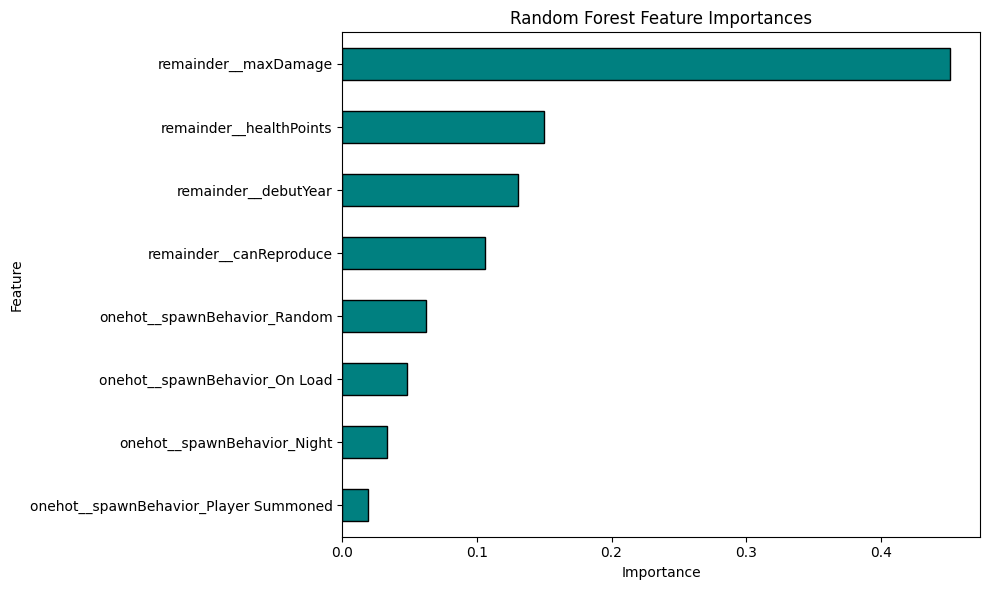

In [ ]:
# Extract the preprocessor and the random forest classifier from the pipeline
rf_preprocessor = rf_model.named_steps['preprocessor']
rf_classifier = rf_model.named_steps['classifier']

# Get the feature names after OneHotEncoding
rf_feature_names = rf_preprocessor.get_feature_names_out()

# Get feature importances
importances = rf_classifier.feature_importances_

# Create a pandas Series for easy plotting
feature_importances = pd.Series(importances, index=rf_feature_names).sort_values(ascending=True)

# Plot the feature importances
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## First Tree in the forest

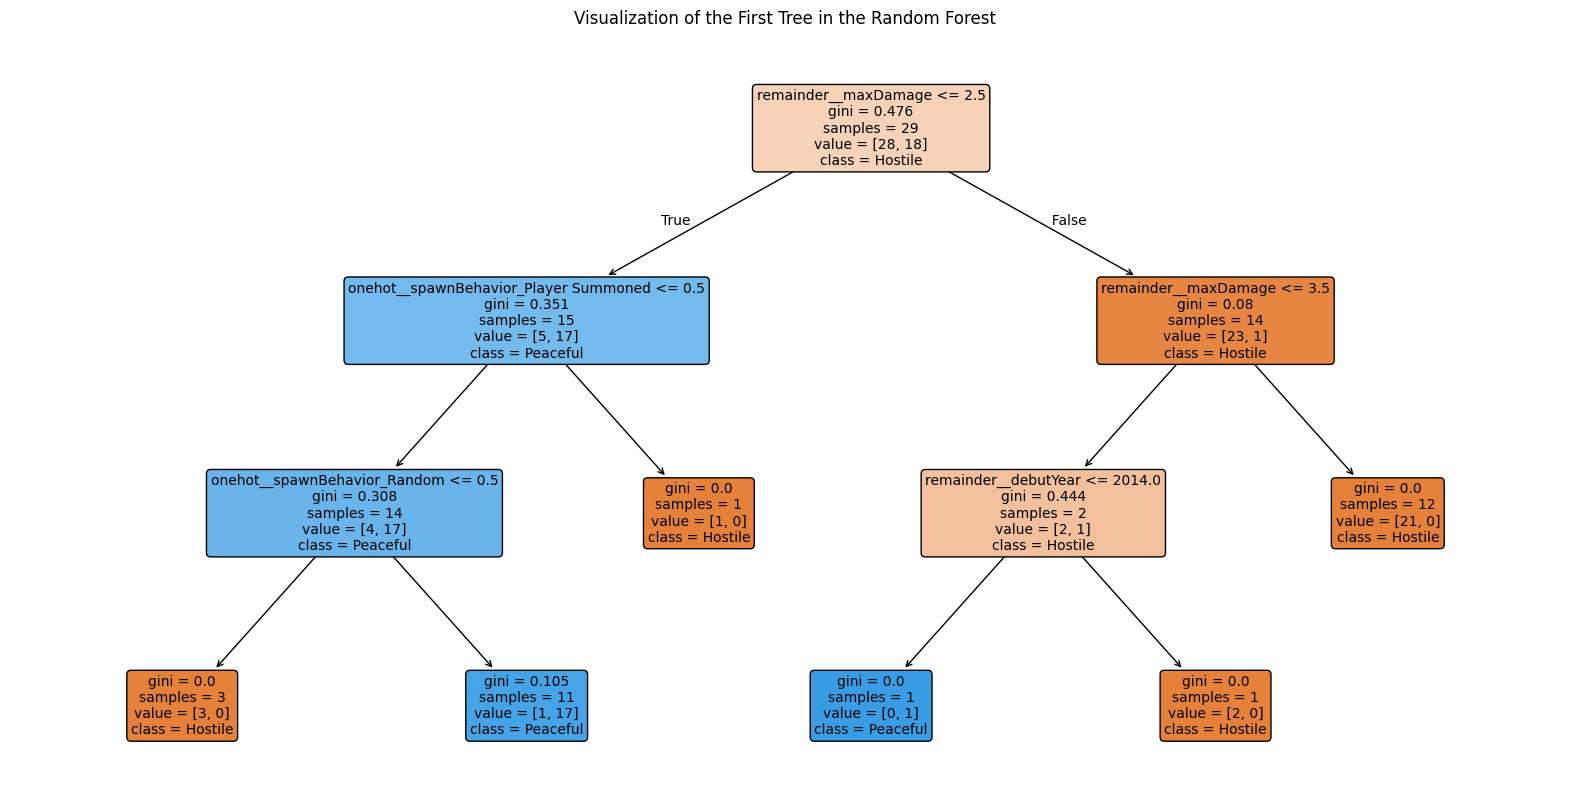

In [ ]:
# Extract the first tree from the Random Forest ensemble
first_tree = rf_model.named_steps['classifier'].estimators_[0]

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(
    first_tree,
    feature_names=rf_feature_names,
    class_names=rf_model.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title('Visualization of the First Tree in the Random Forest')
plt.show()

## Inspecting Misclassifications
Let's see which specific mobs the Random Forest model misclassified by joining the errors back to the original dataset.

In [ ]:
# Find indices where the actual label doesn't match the prediction
misclassified_mask = y_test != rf_pred
misclassified_indices = y_test[misclassified_mask].index

# Get the original rows for the misclassified mobs
misclassified_mobs = mobs_df.loc[misclassified_indices].copy()

# Add the model's incorrect predictions to the dataframe for comparison
misclassified_mobs['Predicted_Behavior'] = rf_pred[misclassified_mask]

# Display the names, actual behaviors, predicted behaviors, and key features
display(misclassified_mobs[['name', 'behaviorTypes', 'Predicted_Behavior', 'healthPoints', 'maxDamage', 'spawnBehavior']])


,name,behaviorTypes,Predicted_Behavior,healthPoints,maxDamage,spawnBehavior
26,pufferfish,Peaceful,Hostile,3,3.0,Random


## Confusion Matrix Comparison
Let's visually compare the mistakes made by the optimized Decision Tree versus the Random Forest.

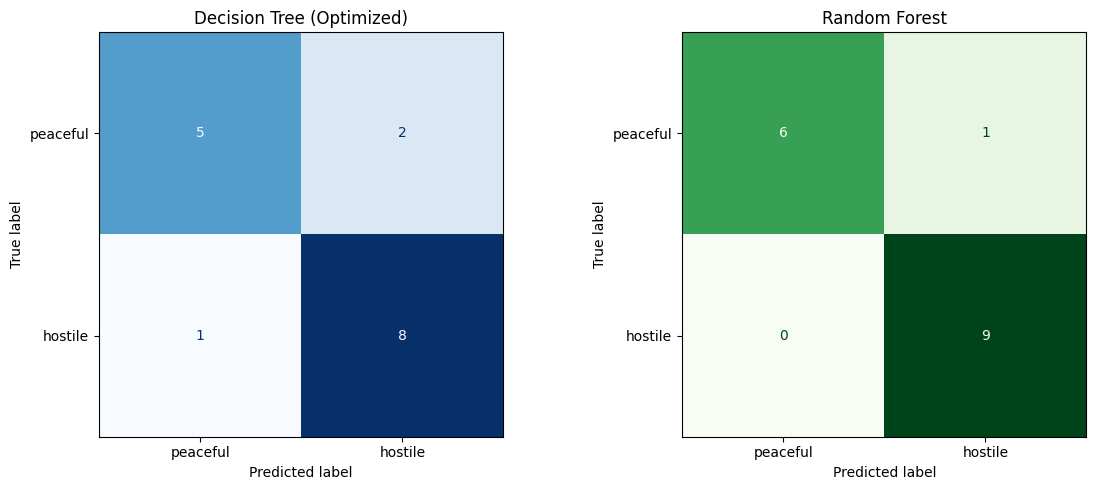

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate confusion matrices
cm_dt = confusion_matrix(y_test, optimized_pred, labels=['Peaceful', 'Hostile'])
cm_rf = confusion_matrix(y_test, rf_pred, labels=['Peaceful', 'Hostile'])

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Decision Tree CM
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['peaceful', 'hostile'])
disp_dt.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Decision Tree (Optimized)')

# Plot Random Forest CM
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['peaceful', 'hostile'])
disp_rf.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()